# Regresión logística en Python
## Caso: abandono de producto financiero

**Curso:** Machine Learning en Economía y Finanzas · FCEA · Clase 9 · 2026-2

En este taller el desenlace es **binario**: el cliente `permanece` (0) o `abandona` (1) la relación con el banco. La estimación se realiza mediante un modelo de regresión logística con `statsmodels` (`logit` / `glm` binomial).


Cuaderno para **Colab** o local. El CSV es `abandono_producto_financiero.csv` (ubicado junto al cuaderno en la raíz del repositorio.).

Cada fila es un cliente observado con desenlace observado: `abandono` = 1 (el cliente cerró la relación) o `abandono` = 0 (el cliente permaneció). El modelo estima $P(y=1 \mid x)$ con $y=1$ si `Abandono` = `1`.

**Respuestas — Punto 1**

**1.** La base cruda tiene **14 variables** (10000 clientes). Tras eliminar `numero_fila`, `id_cliente` y `apellido` quedan **11**: 10 variables explicativas y la respuesta `abandono`.

**2.** Hay **6 cuantitativas**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y `salario_estimado`. `numero_productos` es un conteo entero, pero el enunciado lo trata como continua en el logit.

**3.** Hay **5 categóricas**: `pais` y `sexo` (categóricas), `tiene_tarjeta` y `miembro_activo` (binarias 0/1) y la respuesta `abandono`.

**4.** En la fórmula, `C(pais)` y `C(sexo)` hacen que `statsmodels` cree las dummies automáticamente y deje el primer nivel como referencia. Por eso se fija el orden con `pd.Categorical`: así los coeficientes se leen contra Francia y Mujer. `pais` genera 2 dummies y `sexo` genera 1. Las binarias `tiene_tarjeta` y `miembro_activo` ya son 0/1 y entran directamente, sin `C()`. Habría que omitir un nivel por factor para evitar colinealidad perfecta, con más código y más riesgo de error.

In [6]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from scipy import stats
from IPython.display import display

plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["axes.grid"] = False

CSV = "abandono_producto_financiero.csv"
if not Path(CSV).exists():
    raise FileNotFoundError(
        f"No está {CSV}. Déjelo en la misma carpeta que este cuaderno (raíz del repositorio)."
    )

In [7]:
raw = pd.read_csv(CSV, encoding="utf-8-sig")
raw.head()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
0,1,15634602,Hargrave,619,Francia,Mujer,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,España,Mujer,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,Francia,Mujer,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,Francia,Mujer,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,España,Mujer,43,2,125510.82,1,1,1,79084.10,0


In [8]:
raw.tail()

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
9995,9996,15606229,Obijiaku,771,Francia,Hombre,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,Francia,Hombre,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,Francia,Mujer,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Alemania,Hombre,42,3,75075.31,2,1,0,92888.52,1
9999,10000,15628319,Walker,792,Francia,Mujer,28,4,130142.79,1,1,0,38190.78,0


In [9]:
print(raw.columns.tolist())
print("shape:", raw.shape)

['numero_fila', 'id_cliente', 'apellido', 'puntaje_crediticio', 'pais', 'sexo', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'tiene_tarjeta', 'miembro_activo', 'salario_estimado', 'abandono']
shape: (10000, 14)


In [10]:
raw.describe(include="all")

,numero_fila,id_cliente,apellido,puntaje_crediticio,pais,sexo,edad,antiguedad,saldo,numero_productos,tiene_tarjeta,miembro_activo,salario_estimado,abandono
count,10000.00000,1.000000e+04,10000,10000.000000,10000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,2932,NaN,3,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Smith,NaN,Francia,Hombre,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,32,NaN,5014,5457,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,1.569094e+07,NaN,650.528800,NaN,NaN,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,NaN,96.653299,NaN,NaN,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,NaN,350.000000,NaN,NaN,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,NaN,584.000000,NaN,NaN,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,NaN,652.000000,NaN,NaN,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,NaN,718.000000,NaN,NaN,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000


Se eliminan los tres identificadores. `pais` y `sexo` pasan a `category` con los niveles del diccionario **en ese orden**, para que `C(pais)` y `C(sexo)` usen como referencia Francia y Mujer. `abandono` queda como entero 0/1.

In [11]:
df = raw.drop(columns=["numero_fila", "id_cliente", "apellido"]).copy()

df["pais"] = pd.Categorical(df["pais"], categories=["Francia", "Alemania", "España"])
df["sexo"] = pd.Categorical(df["sexo"], categories=["Mujer", "Hombre"])
df["abandono"] = df["abandono"].astype(int)

print("Referencia de pais:", df["pais"].cat.categories[0])
print("Referencia de sexo:", df["sexo"].cat.categories[0])
print("Valores faltantes en toda la base:", int(df.isna().sum().sum()))
df.dtypes

Referencia de pais: Francia
Referencia de sexo: Mujer
Valores faltantes en toda la base: 0


puntaje_crediticio       int64
pais                  category
sexo                  category
edad                     int64
antiguedad               int64
saldo                  float64
numero_productos         int64
tiene_tarjeta            int64
miembro_activo           int64
salario_estimado       float64
abandono                 int64
dtype: object

In [12]:
cuantitativas = ["puntaje_crediticio", "edad", "antiguedad", "saldo", "numero_productos", "salario_estimado"]
categoricas = ["pais", "sexo", "tiene_tarjeta", "miembro_activo", "abandono"]

print("Variables en la base cruda:      ", raw.shape[1])
print("Variables tras eliminar los IDs: ", df.shape[1], "(10 explicativas + la respuesta)")
print("Cuantitativas:                   ", len(cuantitativas), cuantitativas)
print("Categóricas o binarias:          ", len(categoricas), categoricas)

Variables en la base cruda:       14
Variables tras eliminar los IDs:  11 (10 explicativas + la respuesta)
Cuantitativas:                    6 ['puntaje_crediticio', 'edad', 'antiguedad', 'saldo', 'numero_productos', 'salario_estimado']
Categóricas o binarias:           5 ['pais', 'sexo', 'tiene_tarjeta', 'miembro_activo', 'abandono']


**Respuestas — Punto 1**

**1.** La base cruda tiene **14 variables** (10000 clientes). Tras eliminar `numero_fila`, `id_cliente` y `apellido` quedan **11**: 10 variables explicativas y la respuesta `abandono`.

**2.** Hay **6 cuantitativas**: `puntaje_crediticio`, `edad`, `antiguedad`, `saldo`, `numero_productos` y `salario_estimado`. `numero_productos` es un conteo entero, pero el enunciado lo trata como continua en el logit.

**3.** Hay **5 categóricas**: `pais` y `sexo` (categóricas), `tiene_tarjeta` y `miembro_activo` (binarias 0/1) y la respuesta `abandono`.

**4.** En la fórmula, `C(pais)` y `C(sexo)` hacen que `statsmodels` cree las dummies automáticamente y deje el primer nivel como referencia. Por eso se fija el orden con `pd.Categorical`: así los coeficientes se leen contra Francia y Mujer. `pais` genera 2 dummies y `sexo` genera 1. Las binarias `tiene_tarjeta` y `miembro_activo` ya son 0/1 y entran directamente, sin `C()`. Habría que omitir un nivel por factor para evitar colinealidad perfecta, con más código y más riesgo de error.

# Punto 2. Descriptivo univariado

Conteo, proporción y gráfico de barras.

In [13]:
conteo = df["abandono"].value_counts().sort_index()
prop = df["abandono"].value_counts(normalize=True).sort_index()
pd.DataFrame({"clientes": conteo, "proporcion": prop.round(4), "porcentaje": (prop * 100).round(2)})

,clientes,proporcion,porcentaje
abandono,,,
0,7963,0.7963,79.63
1,2037,0.2037,20.37


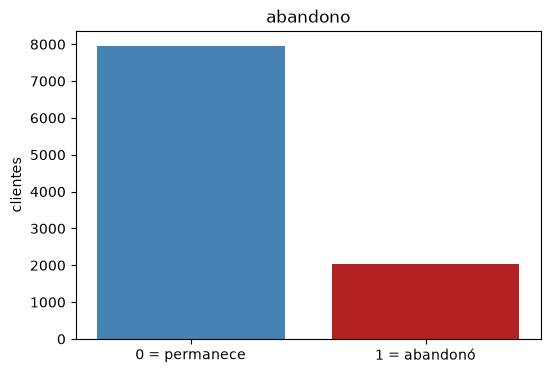

In [14]:
plt.bar(["0 = permanece", "1 = abandonó"], conteo.values, color=["steelblue", "firebrick"])
plt.ylabel("clientes")
plt.title("abandono")
plt.show()

In [15]:
acc_ingenua = 1 - df["abandono"].mean()
print(f"Accuracy de un clasificador que siempre dice 'permanece' (base completa): {acc_ingenua:.4f}")
print(f"Abandonos que detecta: 0 de {int(df['abandono'].sum())}")

Accuracy de un clasificador que siempre dice 'permanece' (base completa): 0.7963
Abandonos que detecta: 0 de 2037


Las variables numéricas: resumen e histogramas.

In [16]:
df[cuantitativas].describe()

,puntaje_crediticio,edad,antiguedad,saldo,numero_productos,salario_estimado
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,650.528800,38.921800,5.012800,76485.889288,1.530200,100090.239881
std,96.653299,10.487806,2.892174,62397.405202,0.581654,57510.492818
min,350.000000,18.000000,0.000000,0.000000,1.000000,11.580000
25%,584.000000,32.000000,3.000000,0.000000,1.000000,51002.110000
50%,652.000000,37.000000,5.000000,97198.540000,1.000000,100193.915000
75%,718.000000,44.000000,7.000000,127644.240000,2.000000,149388.247500
max,850.000000,92.000000,10.000000,250898.090000,4.000000,199992.480000


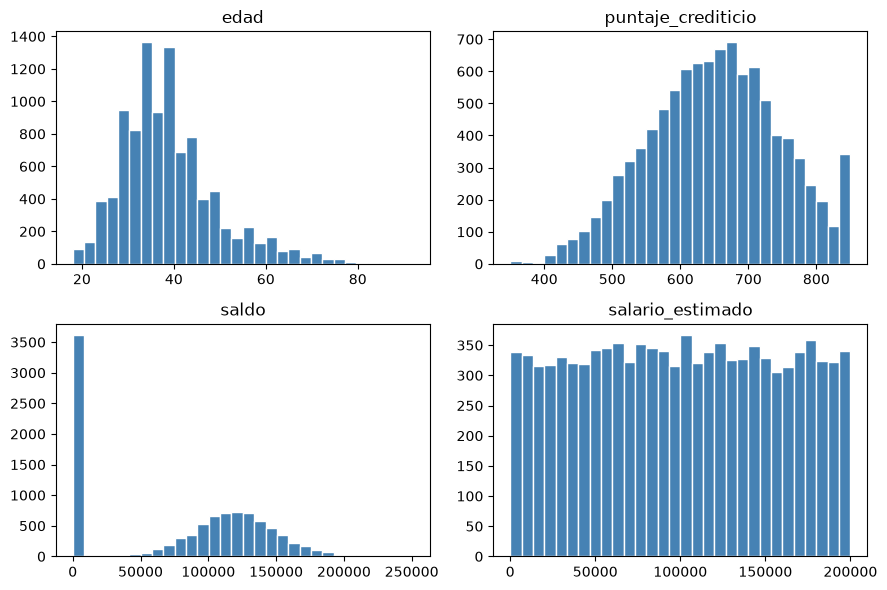

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(9, 6))
for ax, col in zip(axes.ravel(), ["edad", "puntaje_crediticio", "saldo", "salario_estimado"]):
    ax.hist(df[col], bins=30, color="steelblue", edgecolor="white")
    ax.set_title(col)
plt.tight_layout()
plt.show()

Tablas de frecuencia de `pais`, `sexo`, `numero_productos` y `miembro_activo`:

In [18]:
for col in ["pais", "sexo", "numero_productos", "miembro_activo"]:
    n = df[col].value_counts().sort_index()
    pct = (df[col].value_counts(normalize=True).sort_index() * 100).round(2)
    print(f"\n{col}")
    display(pd.DataFrame({"n": n, "%": pct}))


pais


,n,%
pais,,
Francia,5014,50.14
Alemania,2509,25.09
España,2477,24.77



sexo


,n,%
sexo,,
Mujer,4543,45.43
Hombre,5457,54.57



numero_productos


,n,%
numero_productos,,
1,5084,50.84
2,4590,45.90
3,266,2.66
4,60,0.60



miembro_activo


,n,%
miembro_activo,,
0,4849,48.49
1,5151,51.51


El histograma de `saldo` tiene una barra alta en cero. Cuántos clientes tienen saldo 0 y en qué país:

In [19]:
print(f"Clientes con saldo = 0: {(df['saldo'] == 0).sum()} ({(df['saldo'] == 0).mean():.2%})")
(pd.crosstab(df["pais"], df["saldo"] == 0, normalize="index")
   .rename(columns={False: "saldo > 0", True: "saldo = 0"}).round(3))

Clientes con saldo = 0: 3617 (36.17%)


saldo,saldo > 0,saldo = 0
pais,,
Francia,0.518,0.482
Alemania,1.000,0.000
España,0.516,0.484


**Respuesta - Punto 2**

**5**. En la base, el **20,37 %** de los clientes abandonó el producto, es decir, 2037 de los 10.000 clientes. El otro 79,63 % permaneció.

Si hacemos un clasificador que siempre diga que el cliente permanece, tendría una accuracy de **79,63 %**, que a primera vista parece buena. Pero en realidad no identificaría a ninguno de los clientes que abandonó, por lo que su sensibilidad sería 0. Por eso, cuando las clases están desbalanceadas, no es suficiente mirar solamente la accuracy; también debemos revisar otros indicadores, como la sensibilidad y la especificidad.

En general, la edad está más concentrada entre 32 y 44 años, con una mediana de 37 años. Además, el 36,17 % tiene un saldo de 0. La mayoría de los clientes tiene 1 o 2 productos, con 5084 y 4590 clientes, respectivamente; mientras que son pocos los que tienen 3 o 4 productos.

# Punto 3. Bivariado con la respuesta

Distribución de `edad`, `saldo` y `puntaje_crediticio` según `abandono`:

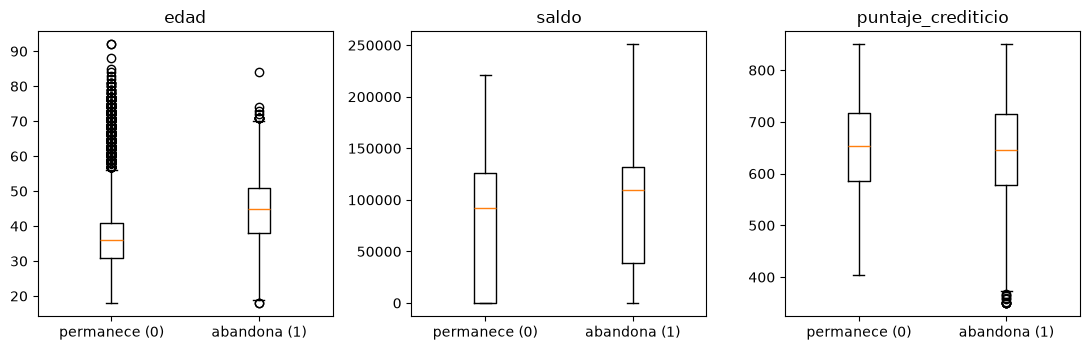

In [20]:
fig, axes = plt.subplots(1, 3, figsize=(11, 3.6))
for ax, col in zip(axes, ["edad", "saldo", "puntaje_crediticio"]):
    grupos = [df.loc[df["abandono"] == g, col] for g in [0, 1]]
    ax.boxplot(grupos)
    ax.set_xticklabels(["permanece (0)", "abandona (1)"])
    ax.set_title(col)
plt.tight_layout()
plt.show()

In [21]:
df.groupby("abandono")[["edad", "saldo", "puntaje_crediticio"]].agg(["median", "mean"]).round(1)

edad           saldo          puntaje_crediticio       
         median  mean    median     mean             median   mean
abandono                                                          
0          36.0  37.4   92072.7  72745.3              653.0  651.9
1          45.0  44.8  109349.3  91108.5              646.0  645.4

La edad no parece afectar el abandono de forma lineal. Tasa de abandono por tramos de edad:

In [22]:
tramo = pd.cut(df["edad"], bins=[17, 30, 40, 50, 60, 100], labels=["18-30", "31-40", "41-50", "51-60", "61+"])
df.groupby(tramo, observed=True)["abandono"].agg(clientes="size", tasa_abandono="mean").round(4)

,clientes,tasa_abandono
edad,,
18-30,1968,0.0752
31-40,4451,0.1209
41-50,2320,0.3397
51-60,797,0.5621
61+,464,0.2478


Tablas cruzadas y ji-cuadrado de `abandono` contra `miembro_activo`, `numero_productos` y `pais`. La columna `tasa_abandono` es la fracción de la fila que abandonó.

In [23]:
def cruzar(col):
    tab = pd.crosstab(df[col], df["abandono"])
    chi2_val, p, dof, _ = stats.chi2_contingency(tab)
    tab["tasa_abandono"] = (tab[1] / (tab[0] + tab[1])).round(4)
    display(tab)
    print(f"{col}: chi2 = {chi2_val:.1f} · gl = {dof} · p = {p:.3g}\n")

cruzar("miembro_activo")

abandono,0,1,tasa_abandono
miembro_activo,,,
0,3547,1302,0.2685
1,4416,735,0.1427


miembro_activo: chi2 = 243.0 · gl = 1 · p = 8.79e-55



In [24]:
cruzar("numero_productos")

abandono,0,1,tasa_abandono
numero_productos,,,
1,3675,1409,0.2771
2,4242,348,0.0758
3,46,220,0.8271
4,0,60,1.0000


numero_productos: chi2 = 1503.6 · gl = 3 · p = 0



In [25]:
cruzar("pais")

abandono,0,1,tasa_abandono
pais,,,
Francia,4204,810,0.1615
Alemania,1695,814,0.3244
España,2064,413,0.1667


pais: chi2 = 301.3 · gl = 2 · p = 3.83e-66



Para comparar la **fuerza** de la relación (el valor $p$ con $n=10000$ es muy pequeño casi siempre), se usa la V de Cramér en las categóricas y la correlación con `abandono` en las continuas:

In [26]:
def cramers_v(col):
    tab = pd.crosstab(df[col], df["abandono"])
    chi2_val = stats.chi2_contingency(tab)[0]
    return np.sqrt(chi2_val / (tab.values.sum() * (min(tab.shape) - 1)))

v = pd.Series({c: cramers_v(c) for c in ["numero_productos", "pais", "miembro_activo", "sexo", "tiene_tarjeta"]})
print("V de Cramér (categóricas):")
display(v.sort_values(ascending=False).round(3))

print("Correlación con abandono (continuas):")
display(df[["edad", "saldo", "puntaje_crediticio", "antiguedad", "salario_estimado", "abandono"]]
        .corr()["abandono"].drop("abandono").sort_values(key=abs, ascending=False).round(3))

V de Cramér (categóricas):


numero_productos    0.388
pais                0.174
miembro_activo      0.156
sexo                0.106
tiene_tarjeta       0.007
dtype: float64

Correlación con abandono (continuas):


edad                  0.285
saldo                 0.119
puntaje_crediticio   -0.027
antiguedad           -0.014
salario_estimado      0.012
Name: abandono, dtype: float64

In [27]:
cruzar("sexo")
cruzar("tiene_tarjeta")

abandono,0,1,tasa_abandono
sexo,,,
Mujer,3404,1139,0.2507
Hombre,4559,898,0.1646


sexo: chi2 = 112.9 · gl = 1 · p = 2.25e-26



abandono,0,1,tasa_abandono
tiene_tarjeta,,,
0,2332,613,0.2081
1,5631,1424,0.2018


tiene_tarjeta: chi2 = 0.5 · gl = 1 · p = 0.492



**Respuestas — Punto 3**

**6.** Quien abandona es **mayor**: la mediana de edad es **45** años frente a **36** de quien permanece, y en el diagrama de cajas y bigotes la caja del grupo «abandona» está desplazada hacia arriba. La relación no es lineal: la tasa de abandono sube de 7.5 % (18–30) a 12.1 % (31–40), 34.0 % (41–50) y 56.2 % (51–60), y cae a 24.8 % en mayores de 60.

**7.** El `saldo` es algo **mayor** entre quienes abandonan (mediana 109349 frente a 92073). El `puntaje_crediticio` es prácticamente igual (mediana 646 frente a 653): la diferencia es pequeña frente a la dispersión, así que por sí solo no discrimina.

**8.** Sí. Entre los clientes **inactivos** abandona el **26.85 %**; entre los **activos**, el **14.27 %**, casi la mitad. La asociación es significativa (chi² = 243.0, gl = 1, p ≈ 9e-55).

**9.** **No.** La relación no es monótona: abandona el 27.7 % con 1 producto, baja a **7.6 % con 2**, pero sube a **82.7 % con 3** y a **100 % con 4**. Tener más productos no protege siempre; pasar de 1 a 2 se asocia con menos abandono, pero 3 o más se asocia con muchísimo más (chi² = 1503.6, gl = 3, p ≈ 0).

**10.** La asociación más fuerte es la de **`numero_productos`** (V de Cramér = 0.388, muy por encima del resto), seguida de `pais` (0.174) y `miembro_activo` (0.156); `sexo` (0.106) es más débil y `tiene_tarjeta` (0.007, p = 0.49) no muestra relación. Entre las continuas, la mayor correlación es la de **`edad`** (0.285); `saldo` (0.119) es baja y las demás son casi nulas.